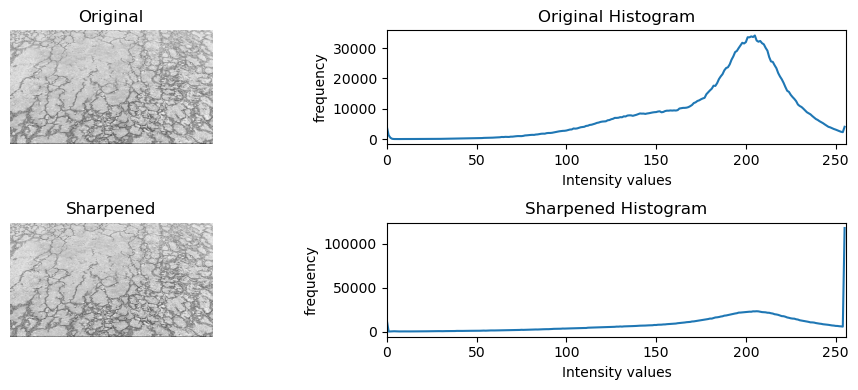

(1080, 1920)


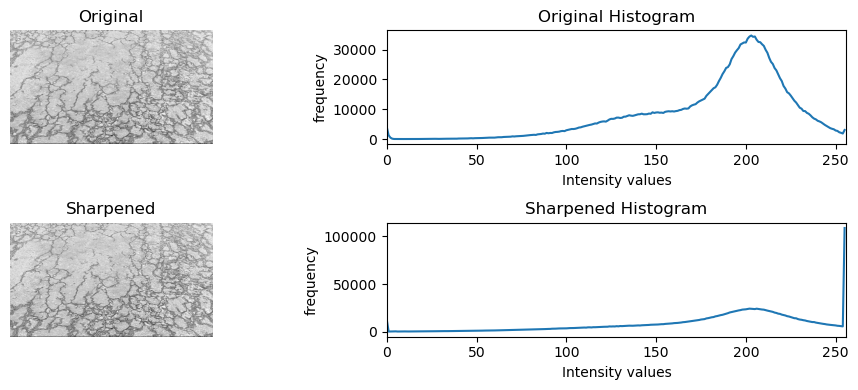

(1080, 1920)


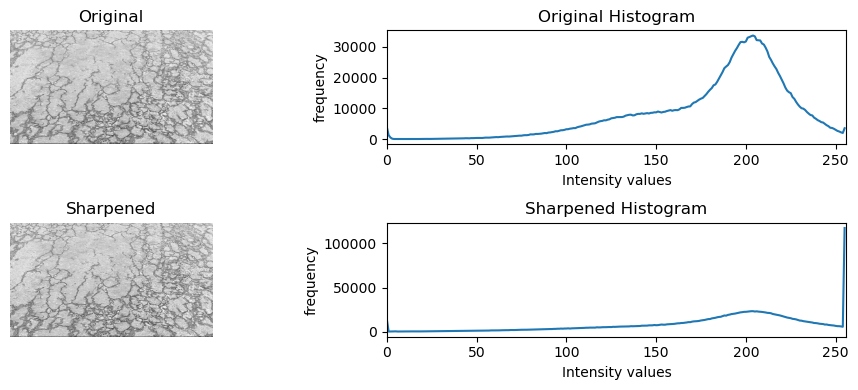

(1080, 1920)


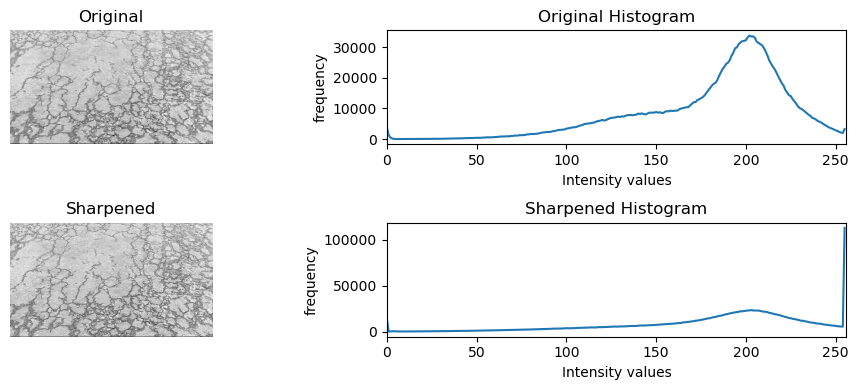

(1080, 1920)


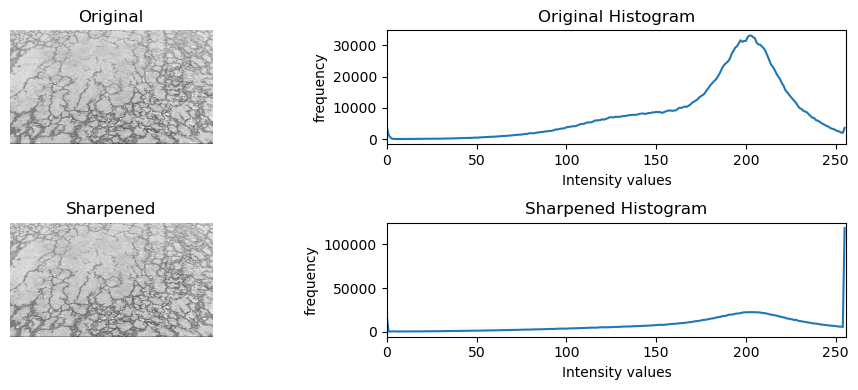

(1080, 1920)


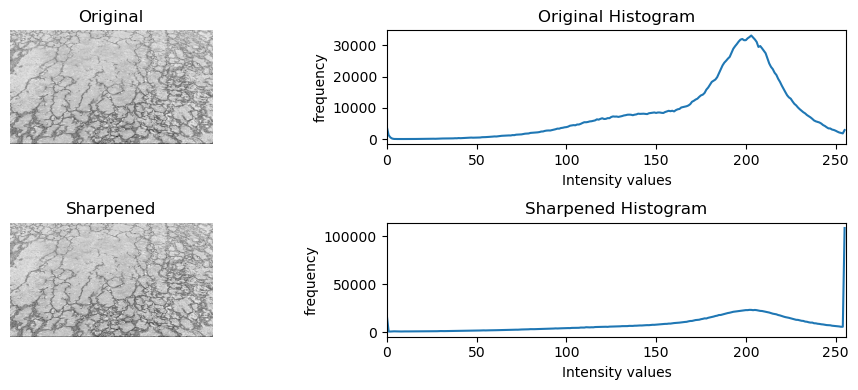

(1080, 1920)


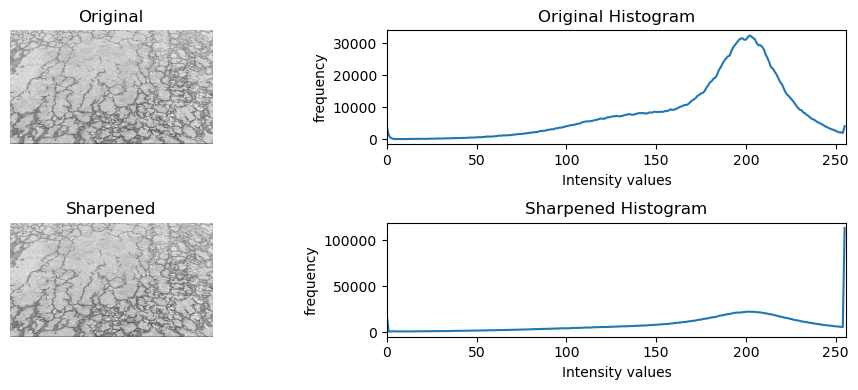

(1080, 1920)


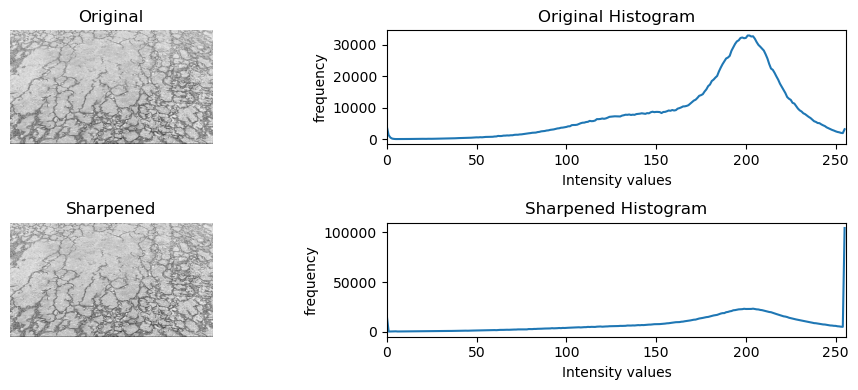

(1080, 1920)


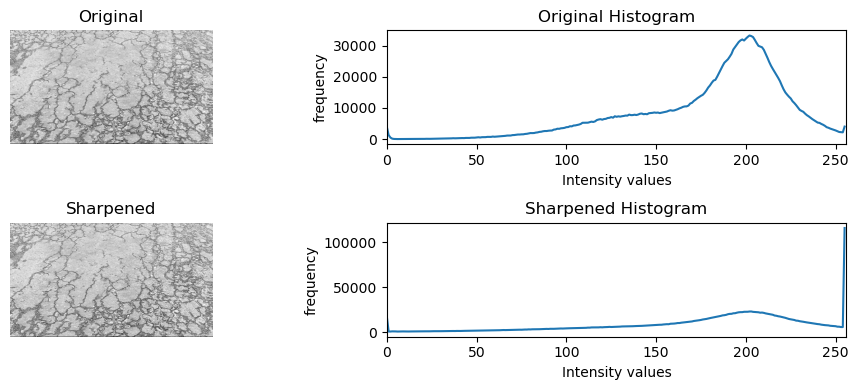

(1080, 1920)


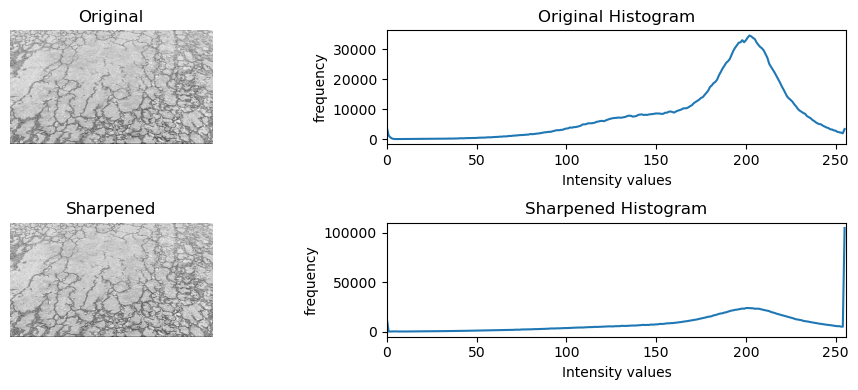

(1080, 1920)


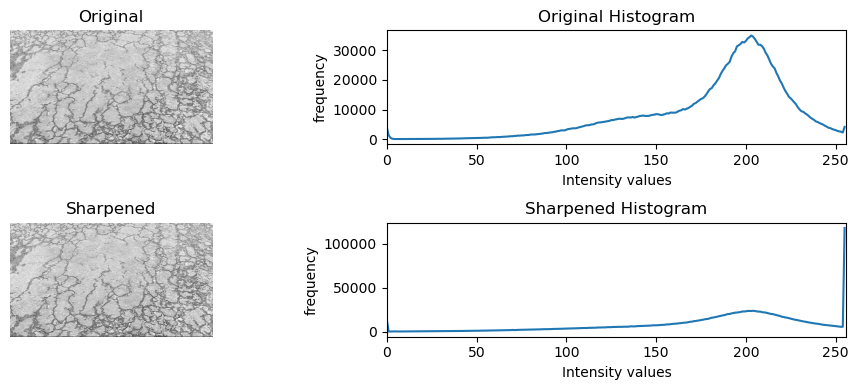

(1080, 1920)


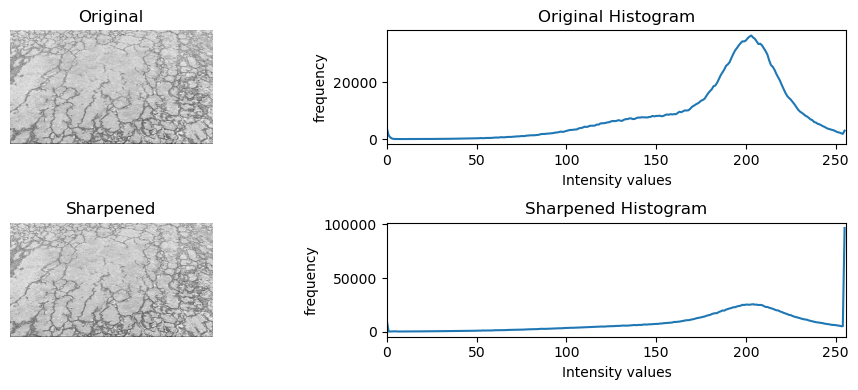

(1080, 1920)


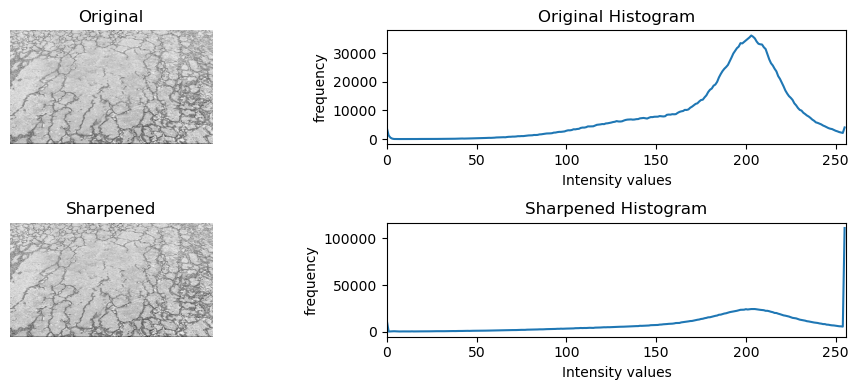

(1080, 1920)


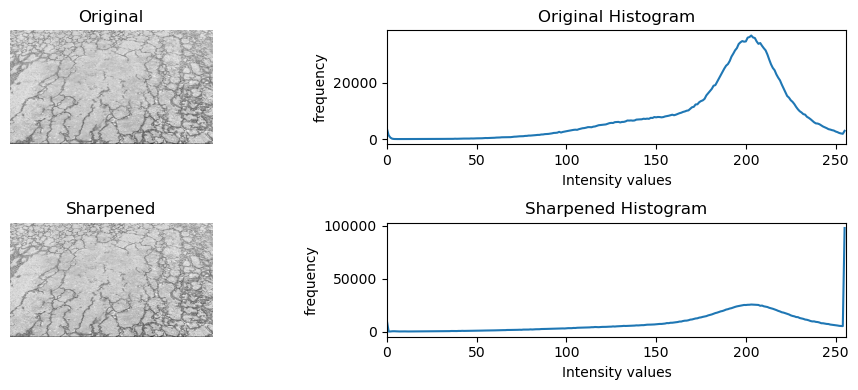

(1080, 1920)


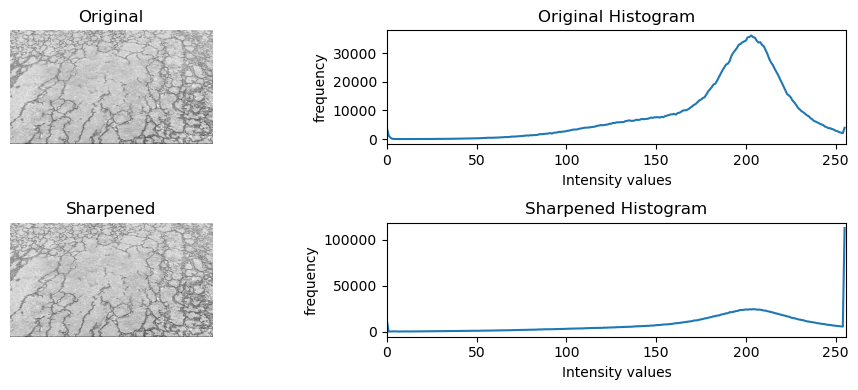

(1080, 1920)


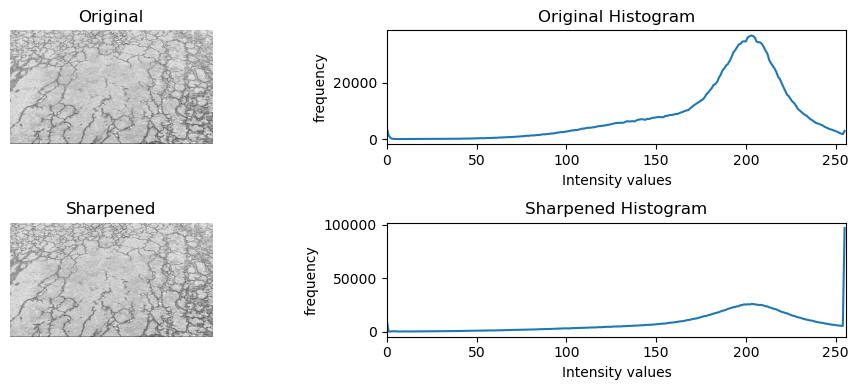

(1080, 1920)


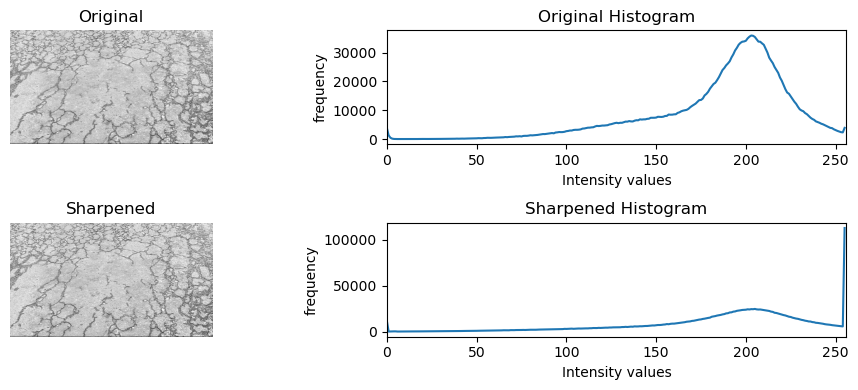

(1080, 1920)


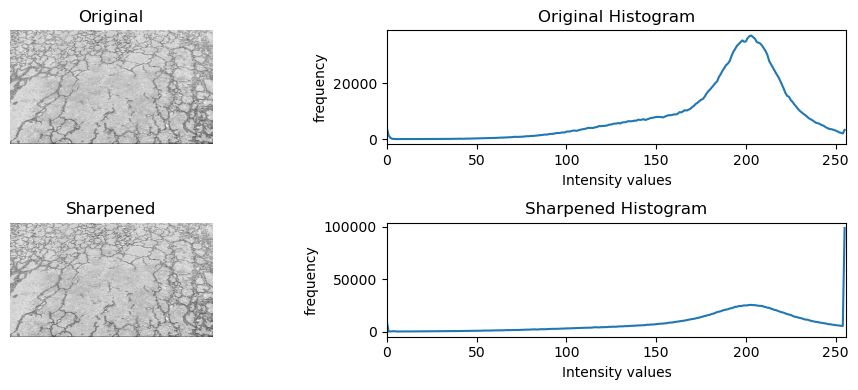

(1080, 1920)


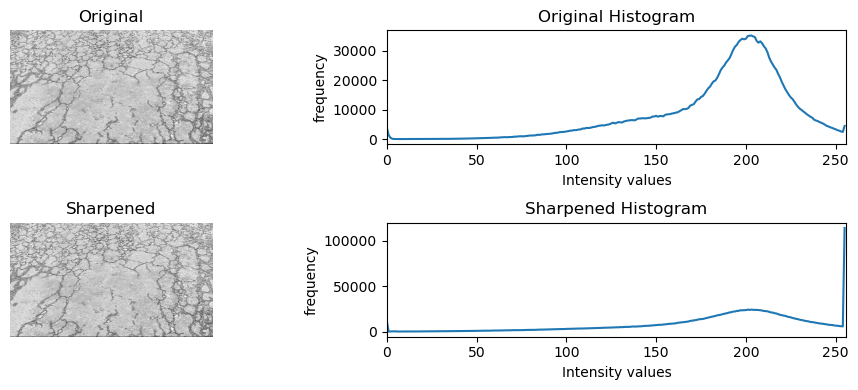

(1080, 1920)


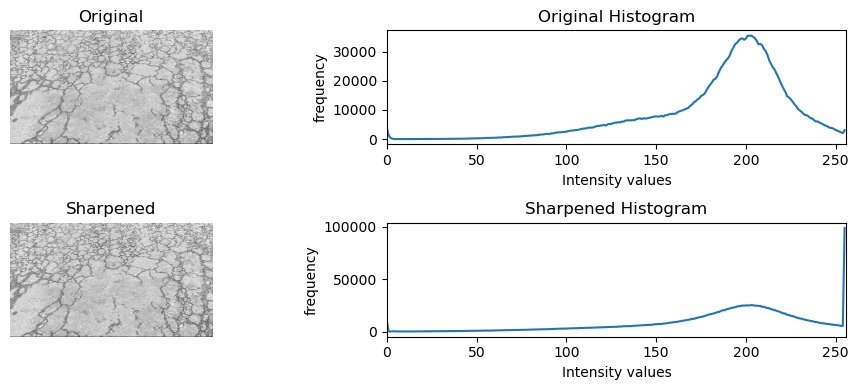

(1080, 1920)


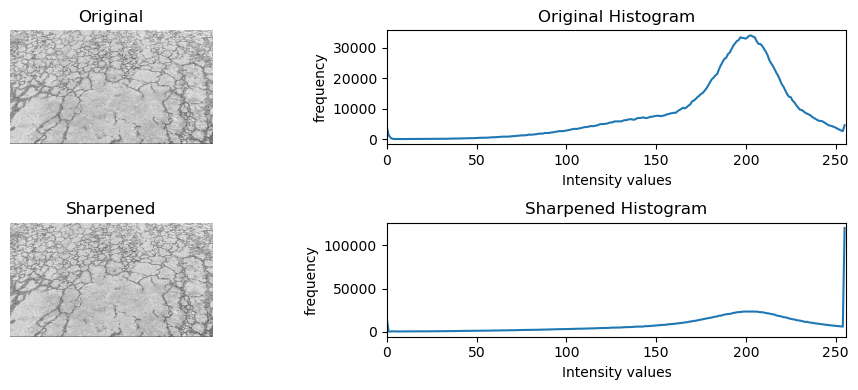

(1080, 1920)


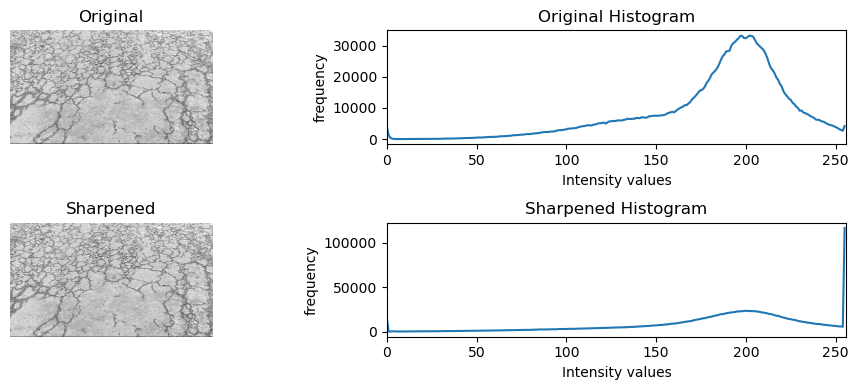

(1080, 1920)


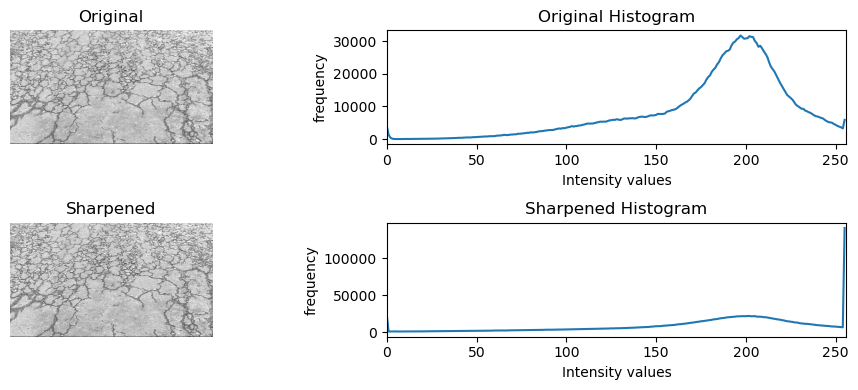

(1080, 1920)


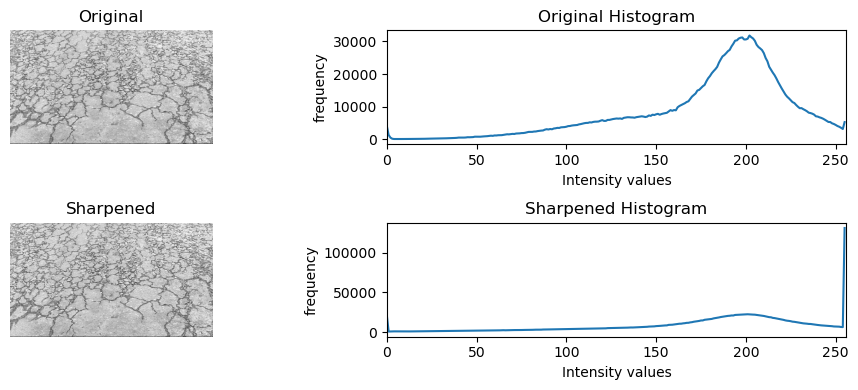

(1080, 1920)


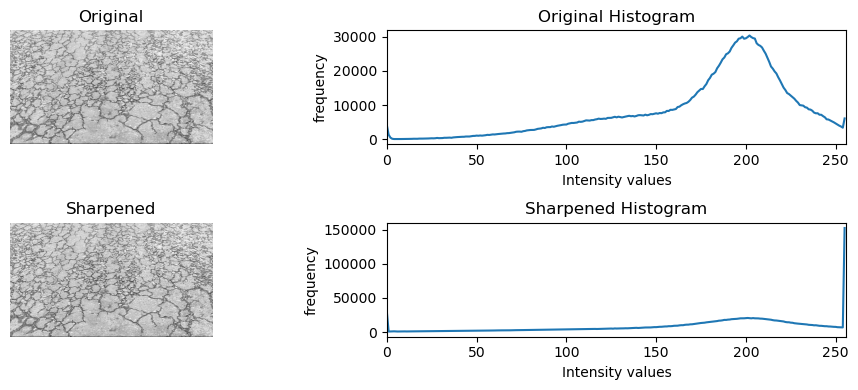

(1080, 1920)


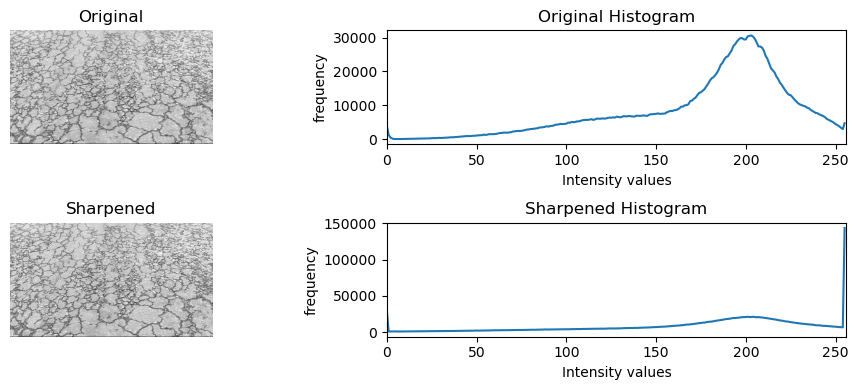

(1080, 1920)


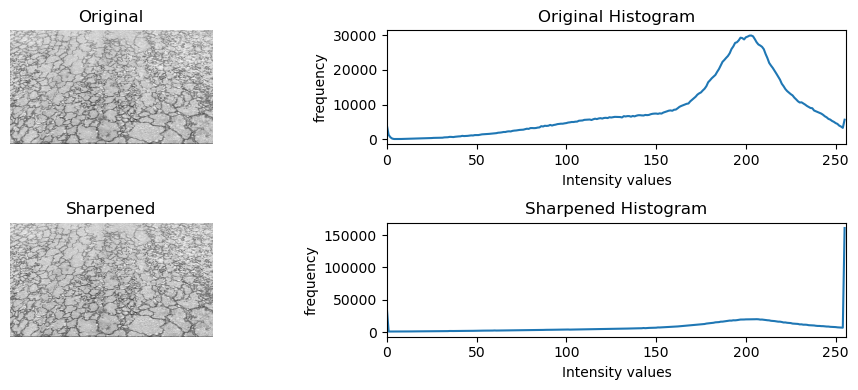

(1080, 1920)


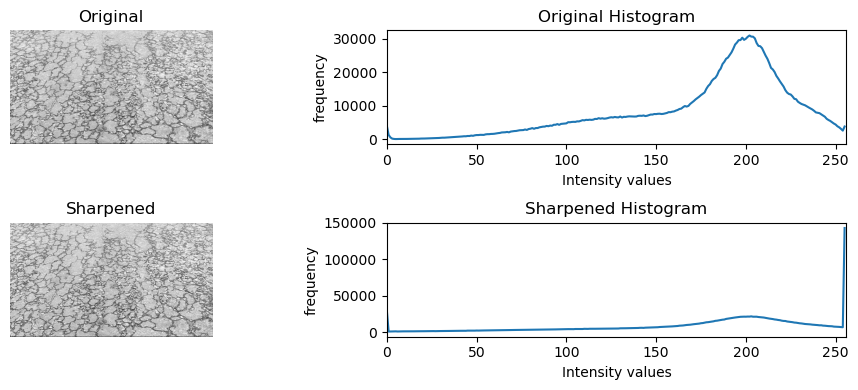

(1080, 1920)


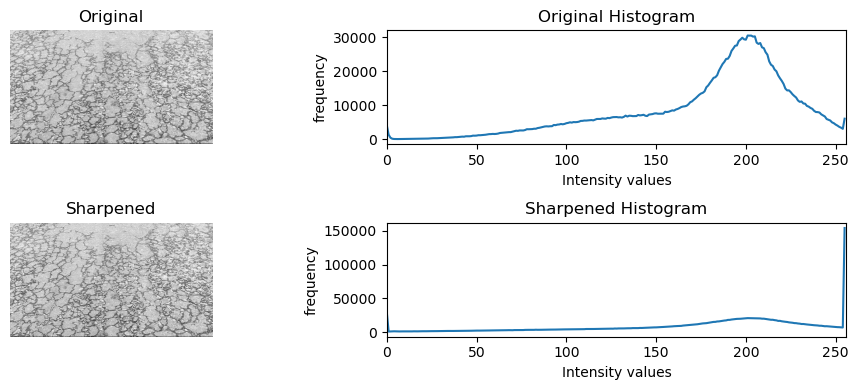

(1080, 1920)


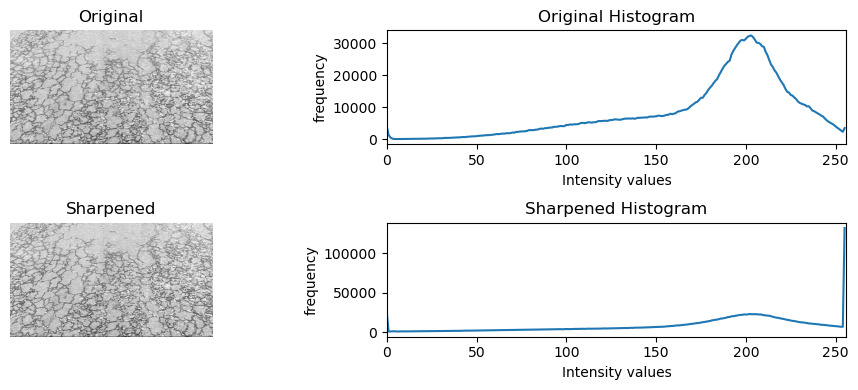

(1080, 1920)
Output Display Completed.


In [4]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

def histogram(image,title):
    histogram = cv2.calcHist([image],[0],None,[256],[0,256])

    plt.title(title)
    plt.xlabel("Intensity values")
    plt.ylabel("frequency")
    plt.plot(histogram)
    plt.xlim([0,256])


input_folder = r"C:\Users\Nimesh\Downloads\ICT2403_New\Frames"
output_folder = r"C:\Users\Nimesh\Downloads\ICT2403_New\Sharpened_Frames"

os.makedirs(output_folder, exist_ok=True)

image_extensions = ('.jpg', '.jpeg', '.png')

for filename in os.listdir(input_folder):

    if filename.lower().endswith(image_extensions):

        path = os.path.join(input_folder, filename)
        img = cv2.imread(path,0)

        if img is None:
            continue

       

        # Calculate sharpness
        laplacian = cv2.Laplacian(img, cv2.CV_64F)
        sharpness = laplacian.var()

        #print(f"{filename} → Sharpness: {round(sharpness,2)}")

        # Apply sharpening (for demo always apply)
        sharpened = img - laplacian
        sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

        # Save result
        cv2.imwrite(os.path.join(output_folder, filename), sharpened)

        # ---------------- DISPLAY OUTPUT ----------------
        plt.figure(figsize=(10,4))

        plt.subplot(2,2,1)
        plt.imshow(img, cmap='gray')
        plt.title("Original")
        plt.axis("off")

        plt.subplot(2,2,2)
        histogram(img,"Original Histogram")

        plt.subplot(2,2,3)
        plt.imshow(sharpened, cmap='gray')
        plt.title("Sharpened")
        plt.axis("off")

        plt.subplot(2,2,4)
        histogram(sharpened,"Sharpened Histogram")

        cv2.imwrite(os.path.join(output_folder, f"{os.path.splitext(filename)[0]}_sharpened.png"), sharpened)
        plt.tight_layout()
        plt.show()

        print(img.shape)

print("Output Display Completed.")